# RQ3 — Value of the 500 m neighbourhood analysis

**Research question:** Does a 500 m neighbourhood analysis add value over a parcel-only analysis?

The risk classifier uses three rules. **Rule 1** is parcel-only (the parcel's own model
probability + its tree cover). **Rules 2 and 3** bring in the **500 m neighbourhood**
(the share of nearby pixels already cleared, and how the parcel's greenness compares with
its surroundings). This notebook quantifies how often the neighbourhood *changes* the
verdict — the cumulative-impact evidence a parcel-only permit check would miss.

**Method:** sample 3,000 parcels from the national set; for each, reproduce the app's live
logic — the 25 nearest pixels give the parcel probability and the 500 m neighbourhood
statistics. Classify each parcel twice: **parcel-only (Rule 1)** vs **full (all rules)**,
and measure how many are escalated by the neighbourhood.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import pickle
from scipy.spatial import cKDTree

import matplotlib.pyplot as plt

HERE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

FEATURE_COLS = ['EVI_train', 'NBR_train', 'NDVI_change', 'NDVI_test', 'NDVI_train',
                'NIR_train', 'RED_train', 'SWIR_test', 'SWIR_train', 'VH_VV_ratio',
                'VH_test', 'VH_train', 'VV_test', 'VV_train', 'aspect', 'elevation',
                'slope']
N_SAMPLE = 3000
SEED = 42

## 1. Load the national model and the training data

We use the deployed national Random Forest (`rf_D_national.pkl`) and the national feature
table. Each row's coordinates are parsed so we can build a spatial index (KD-tree) for the
nearest-pixel lookups.

In [2]:
model = pickle.load(open(HERE / "models" / "rf_D_national.pkl", "rb"))
df = pd.read_csv(HERE / "data" / "raw" / "training_data_national.csv")

geo = df['.geo'].apply(lambda s: json.loads(s)['coordinates'])
df['lng'] = geo.apply(lambda c: c[0])
df['lat'] = geo.apply(lambda c: c[1])
tree = cKDTree(df[['lat', 'lng']].values)

print(f"Loaded {len(df):,} national pixels; model expects {model.n_features_in_} features")

Loaded 23,319 national pixels; model expects 17 features


## 2. The classifier — parcel-only vs full (all three rules)

This is the exact logic the web app applies. `parcel_only` uses **Rule 1** alone; `full`
adds the neighbourhood **Rules 2 and 3**.

In [3]:
def classify(prob, ndvi_current, defor_pct_500m, avg_ndvi_500m):
    """Return (parcel_only_level, full_level) using the app's 3 rules."""
    tree_cover_pct = max(0.0, min(100.0, ndvi_current * 100.0))
    rule1_high = (prob > 0.65) or (tree_cover_pct < 30)
    rule2_high = (defor_pct_500m > 50) and (ndvi_current < avg_ndvi_500m * 0.70)
    rule3_med  = (0.35 < prob <= 0.65) and (defor_pct_500m > 0)

    parcel_only = 'HIGH' if rule1_high else 'LOW'          # Rule 1 only
    if rule1_high or rule2_high:
        full = 'HIGH'
    elif rule3_med:
        full = 'MEDIUM'
    else:
        full = 'LOW'
    return parcel_only, full

## 3. Run the analysis on 3,000 sampled parcels

For each sampled parcel we take its 25 nearest pixels: their median features give the
model probability, and their labels/greenness give the 500 m neighbourhood statistics.

In [4]:
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(df), size=min(N_SAMPLE, len(df)), replace=False)

RANK = {'LOW': 0, 'MEDIUM': 1, 'HIGH': 2}
rows = []
for i in sample_idx:
    lat, lng = df.iloc[i]['lat'], df.iloc[i]['lng']
    _, idx = tree.query([lat, lng], k=25)
    nbrs = df.iloc[idx]
    feats = nbrs[FEATURE_COLS].median().values.reshape(1, -1)
    prob = float(model.predict_proba(feats)[0][1])
    ndvi_current   = float(nbrs['NDVI_test'].median())
    defor_pct_500m = float(nbrs['label'].mean() * 100)
    avg_ndvi_500m  = float(nbrs['NDVI_test'].mean())
    p_only, full = classify(prob, ndvi_current, defor_pct_500m, avg_ndvi_500m)
    rows.append((p_only, full))

res = pd.DataFrame(rows, columns=['parcel_only', 'full'])
res['escalated'] = res.apply(lambda r: RANK[r['full']] > RANK[r['parcel_only']], axis=1)
print(f"Classified {len(res):,} parcels")
res.head()

Classified 3,000 parcels


,parcel_only,full,escalated
0,LOW,MEDIUM,True
1,LOW,LOW,False
2,LOW,LOW,False
3,HIGH,HIGH,False
4,HIGH,HIGH,False


## 4. Summarise and save the result

We record the two distributions, how many parcels the neighbourhood escalated, and the
exact transitions — then write `results/metrics/rq3_neighbourhood.json` (the file the
Results chapter cites).

In [5]:
n = len(res)
escalated = int(res['escalated'].sum())
trans = (res[res['escalated']]
         .groupby(['parcel_only', 'full']).size()
         .rename('n').reset_index())

summary = {
    "method": "3000 sampled national parcels; 25-NN parcel prob + 500 m neighbourhood",
    "n_parcels": n,
    "parcel_only_distribution": res['parcel_only'].value_counts().to_dict(),
    "full_distribution": res['full'].value_counts().to_dict(),
    "n_escalated_by_neighbourhood": escalated,
    "pct_escalated_by_neighbourhood": round(100 * escalated / n, 1),
    "transitions": {f"{r.parcel_only}->{r.full}": int(r.n) for r in trans.itertuples()},
    "interpretation": (
        f"{escalated} of {n} parcels ({round(100*escalated/n,1)}%) were raised to a "
        "higher risk level by the 500 m neighbourhood - clearings a parcel-only "
        "permit check would not flag."
    ),
}

out = HERE / "results" / "metrics" / "rq3_neighbourhood.json"
out.write_text(json.dumps(summary, indent=2))
print(json.dumps(summary, indent=2))

{
  "method": "3000 sampled national parcels; 25-NN parcel prob + 500 m neighbourhood",
  "n_parcels": 3000,
  "parcel_only_distribution": {
    "LOW": 1586,
    "HIGH": 1414
  },
  "full_distribution": {
    "HIGH": 1414,
    "LOW": 1226,
    "MEDIUM": 360
  },
  "n_escalated_by_neighbourhood": 360,
  "pct_escalated_by_neighbourhood": 12.0,
  "transitions": {
    "LOW->MEDIUM": 360
  },
  "interpretation": "360 of 3000 parcels (12.0%) were raised to a higher risk level by the 500 m neighbourhood - clearings a parcel-only permit check would not flag."
}


## 5. Figure — the neighbourhood's effect on classification

The chart contrasts the parcel-only and with-neighbourhood risk distributions. The
neighbourhood raises a block of otherwise-LOW parcels into a new MEDIUM (caution) tier,
while HIGH is unchanged.

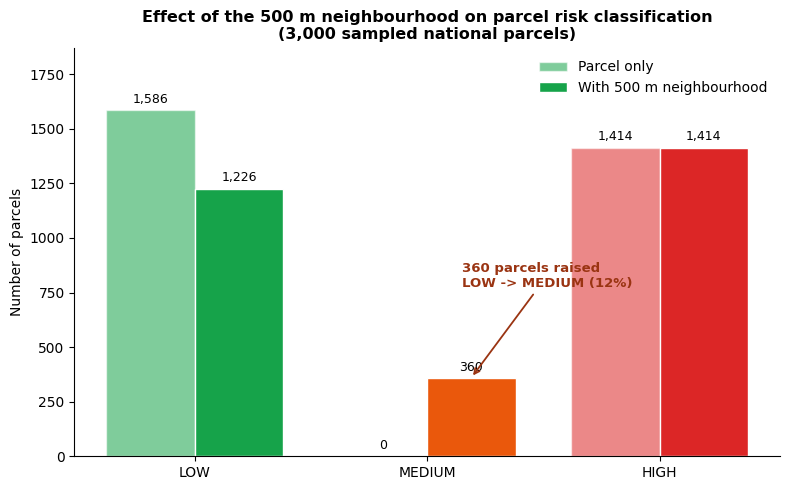

In [6]:
po = summary["parcel_only_distribution"]
fu = summary["full_distribution"]
cats = ["LOW", "MEDIUM", "HIGH"]
parcel_only = [po.get(c, 0) for c in cats]
with_nbhd   = [fu.get(c, 0) for c in cats]
colors = {"LOW": "#16a34a", "MEDIUM": "#ea580c", "HIGH": "#dc2626"}
esc = summary["n_escalated_by_neighbourhood"]
pct = summary["pct_escalated_by_neighbourhood"]

x = np.arange(len(cats)); w = 0.38
fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, parcel_only, w, label="Parcel only",
            color=[colors[c] for c in cats], alpha=0.55, edgecolor="white")
b2 = ax.bar(x + w/2, with_nbhd, w, label="With 500 m neighbourhood",
            color=[colors[c] for c in cats], edgecolor="white")
for bars in (b1, b2):
    for r in bars:
        h = r.get_height()
        ax.annotate(f"{int(h):,}", (r.get_x() + r.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha="center", va="bottom", fontsize=9)
ax.annotate(f"{esc} parcels raised\nLOW -> MEDIUM ({pct:.0f}%)",
            xy=(1 + w/2, with_nbhd[1]), xytext=(1.15, max(with_nbhd)*0.55),
            fontsize=9.5, color="#9a3412", fontweight="bold",
            arrowprops=dict(arrowstyle="->", color="#9a3412", lw=1.3))
ax.set_xticks(x); ax.set_xticklabels(cats)
ax.set_ylabel("Number of parcels")
ax.set_title("Effect of the 500 m neighbourhood on parcel risk classification\n"
             f"({n:,} sampled national parcels)", fontsize=11.5, fontweight="bold")
ax.legend(frameon=False, loc="upper right")
ax.spines[["top", "right"]].set_visible(False)
ax.set_ylim(0, max(with_nbhd + parcel_only) * 1.18)
fig.tight_layout()
fig.savefig(HERE / "results" / "metrics" / "rq3_neighbourhood.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Interpretation

Under the parcel-only assessment the 3,000 parcels split into LOW and HIGH. Adding the
500 m neighbourhood raises **~12%** of the otherwise-LOW parcels to a new **MEDIUM**
tier, while HIGH is unchanged. These are parcels whose own signal looks safe but which
sit in actively-cleared surroundings — the cumulative-impact cases a parcel-only permit
review would pass.

This result quantifies the additional **caution coverage** the neighbourhood provides —
the proportion of parcels it surfaces for closer review — rather than a validated accuracy
improvement, since no independent ground truth exists to confirm each individual
escalation. Establishing that would require the parcel-level re-validation noted in the
recommendations.